In [8]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from tqdm import tqdm
from ipywidgets import interact, IntSlider
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.ticker import ScalarFormatter
from scipy.optimize import curve_fit
import os


import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
import os
import pickle
#### PLOT THE DATA #######
# Generalized variables
textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/laser_cooling_future_ions/'

In [9]:
from ion_properties import lead,xenon,calcium,xenon2nd


Also plot dp/p

min laser_offset horizontal: -1.2416107382550332
min laser offset longitudinal: 0.5704697986577186


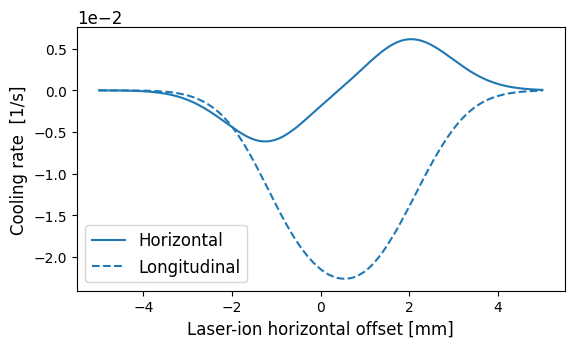

min laser_offset horizontal: -1.3087248322147649
min laser offset longitudinal: 0.5704697986577186


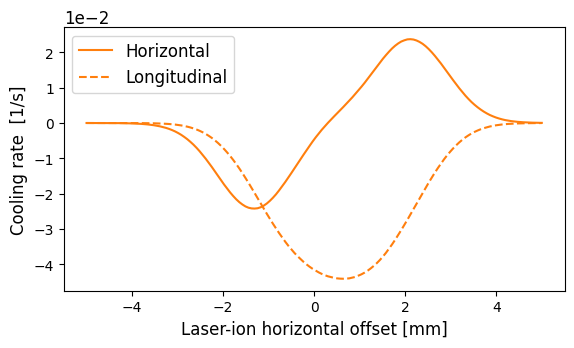

min laser_offset horizontal: -1.5100671140939594
min laser offset longitudinal: 0.7718120805369133


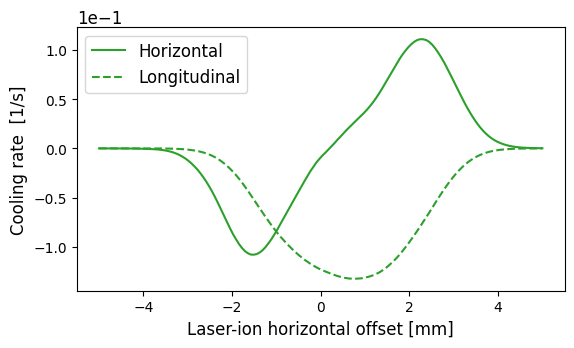

min laser_offset horizontal: -1.3087248322147649
min laser offset longitudinal: 0.5033557046979871


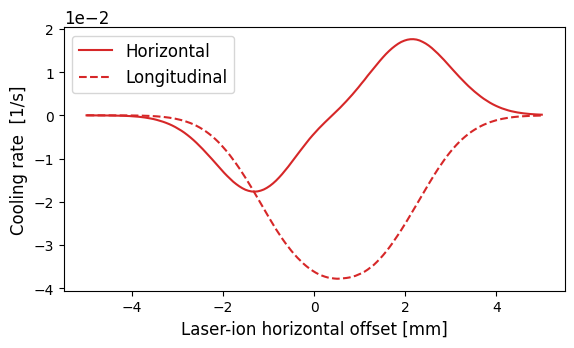

In [10]:
fig=plt.figure(figsize=(fig_width, fig_height))

image_name_list=['lead','xenon','calcium','xenon2nd']

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i,ion_loop in enumerate([lead,xenon,calcium,xenon2nd]):# Ion properties:       
    data = np.load(f'results/optimal_laser_x/{ion_loop.name}.npz')

    # Access the variables stored in the file
    transverse_growth_rate_list = data['transverse_growth_rate_list']
    final_emittance_list = data['final_emittance_list']
    final_dp_p=data['final_dp_p']
    longitudinal_growth_rate_emittance_list=data['longitudinal_growth_rate_emittance_list']
    longitudinal_growth_rate_dp_p_list=data['longitudinal_growth_rate_dp_p_list']
    laser_x_list = data['laser_x_list']
    nemitt = data['nemitt']
    time = data['time']

    ######################################################################
    # Find laser position with minimal final emittance

    min_index = np.argmin(final_emittance_list)
    min_emittance = final_emittance_list[min_index]
    min_laser_offset_transverse = laser_x_list[min_index]

    min_longitudinal_index = np.argmin(final_dp_p)
    min_laser_offset_longitudinal = laser_x_list[min_longitudinal_index]

    print('min laser_offset horizontal:',min_laser_offset_transverse*1e3)    
    print('min laser offset longitudinal:',min_laser_offset_longitudinal*1e3)    
    
    
    plt.plot(laser_x_list*1e3,transverse_growth_rate_list,label=f'Horizontal',color=cycle[i])
    plt.plot(laser_x_list*1e3,longitudinal_growth_rate_emittance_list,label=f'Longitudinal',color=cycle[i],ls='--')
    
    plt.xlabel('Laser-ion horizontal offset [mm]', fontsize=label_fontsize)
    plt.ylabel('Cooling rate  [1/s]', fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    ax = plt.gca()
    # Removing the offset from the y-axis tick labels
    ax.yaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.offsetText.set_fontsize(legend_fontsize)  # Reduce font size
    # plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    # plt.axvline(-1.3758389261744963*1e-3,color='red',label='opt. transverse cooling')
    #plt.axvline(-0.5033557046979862*1e-3,color='black',label='counteract IBS')
        
    # plt.ylim([-0.36,0.35])
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)

    # Save image
    image_name = f'cooling_rate_{image_name_list[i]}.pdf'
    save_location = os.path.join(save_dir, image_name)
    plt.savefig(save_location, dpi=300, bbox_inches='tight')
    # Define your pickle filename
    pickle_filename = f'cooling_rate_{image_name_list[i]}.pkl'
    pickle_file_path = os.path.join(save_dir, pickle_filename)
    # Save the figure object 'fig' using pickle
    with open(pickle_file_path, 'wb') as f:
        pickle.dump(fig, f)


    plt.show()

  

min laser_offset horizontal: -1.2416107382550332
min laser offset longitudinal: 0.5704697986577186
min laser_offset horizontal: -1.3087248322147649
min laser offset longitudinal: 0.5704697986577186
min laser_offset horizontal: -1.5100671140939594
min laser offset longitudinal: 0.7718120805369133


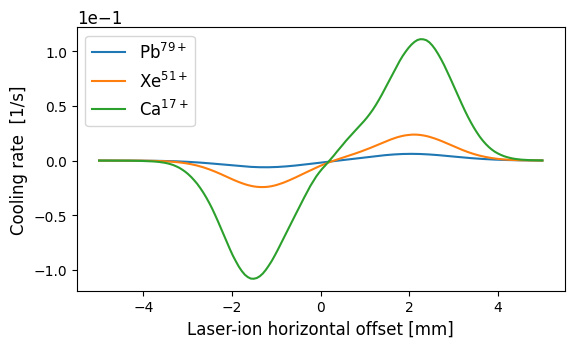

In [11]:
plt.figure(figsize=(fig_width, fig_height))

image_name_list=['lead','xenon','calcium']

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i,ion_loop in enumerate([lead,xenon,calcium]):# Ion properties:       
    data = np.load(f'results/optimal_laser_x/{ion_loop.name}.npz')

    # Access the variables stored in the file
    transverse_growth_rate_list = data['transverse_growth_rate_list']
    final_emittance_list = data['final_emittance_list']
    final_dp_p=data['final_dp_p']
    longitudinal_growth_rate_emittance_list=data['longitudinal_growth_rate_emittance_list']
    longitudinal_growth_rate_dp_p_list=data['longitudinal_growth_rate_dp_p_list']
    laser_x_list = data['laser_x_list']
    nemitt = data['nemitt']
    time = data['time']

    ######################################################################
    # Find laser position with minimal final emittance

    min_index = np.argmin(final_emittance_list)
    min_emittance = final_emittance_list[min_index]
    min_laser_offset_transverse = laser_x_list[min_index]

    min_longitudinal_index = np.argmin(final_dp_p)
    min_laser_offset_longitudinal = laser_x_list[min_longitudinal_index]

    print('min laser_offset horizontal:',min_laser_offset_transverse*1e3)    
    print('min laser offset longitudinal:',min_laser_offset_longitudinal*1e3)    
    
    
    plt.plot(laser_x_list*1e3,transverse_growth_rate_list,label=f'{ion_loop.name}',color=cycle[i])
    #plt.plot(laser_x_list*1e3,longitudinal_growth_rate_emittance_list,label=f'Longitudinal',color=cycle[i],ls='--')
    
    plt.xlabel('Laser-ion horizontal offset [mm]', fontsize=label_fontsize)
    plt.ylabel('Cooling rate  [1/s]', fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    ax = plt.gca()
    # Removing the offset from the y-axis tick labels
    ax.yaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.offsetText.set_fontsize(legend_fontsize)  # Reduce font size
    # plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    # plt.axvline(-1.3758389261744963*1e-3,color='red',label='opt. transverse cooling')
    #plt.axvline(-0.5033557046979862*1e-3,color='black',label='counteract IBS')
    
    # plt.ylim([-0.36,0.35])
plt.tight_layout()
plt.legend(fontsize=legend_fontsize)


# Save image
image_name = 'cooling_rate_transverse_ions.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'cooling_rate_transverse_ions.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

# Display the plot
plt.show()

min laser_offset horizontal: -1.2416107382550332
min laser offset longitudinal: 0.5704697986577186
min laser_offset horizontal: -1.3087248322147649
min laser offset longitudinal: 0.5704697986577186
min laser_offset horizontal: -1.5100671140939594
min laser offset longitudinal: 0.7718120805369133


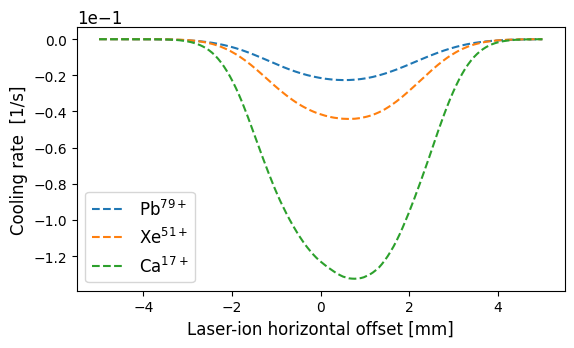

In [12]:
plt.figure(figsize=(fig_width, fig_height))

image_name_list=['lead','xenon','calcium']

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i,ion_loop in enumerate([lead,xenon,calcium]):# Ion properties:       
    data = np.load(f'results/optimal_laser_x/{ion_loop.name}.npz')

    # Access the variables stored in the file
    transverse_growth_rate_list = data['transverse_growth_rate_list']
    final_emittance_list = data['final_emittance_list']
    final_dp_p=data['final_dp_p']
    longitudinal_growth_rate_emittance_list=data['longitudinal_growth_rate_emittance_list']
    longitudinal_growth_rate_dp_p_list=data['longitudinal_growth_rate_dp_p_list']
    laser_x_list = data['laser_x_list']
    nemitt = data['nemitt']
    time = data['time']

    ######################################################################
    # Find laser position with minimal final emittance

    min_index = np.argmin(final_emittance_list)
    min_emittance = final_emittance_list[min_index]
    min_laser_offset_transverse = laser_x_list[min_index]

    min_longitudinal_index = np.argmin(final_dp_p)
    min_laser_offset_longitudinal = laser_x_list[min_longitudinal_index]

    print('min laser_offset horizontal:',min_laser_offset_transverse*1e3)    
    print('min laser offset longitudinal:',min_laser_offset_longitudinal*1e3)    
    
    
    #plt.plot(laser_x_list*1e3,transverse_growth_rate_list,label=f'{ion_loop.name}',color=cycle[i])
    plt.plot(laser_x_list*1e3,longitudinal_growth_rate_emittance_list,label=f'{ion_loop.name}',color=cycle[i],ls='--')
    
    plt.xlabel('Laser-ion horizontal offset [mm]', fontsize=label_fontsize)
    plt.ylabel('Cooling rate  [1/s]', fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    ax = plt.gca()
    # Removing the offset from the y-axis tick labels
    ax.yaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.offsetText.set_fontsize(legend_fontsize)  # Reduce font size
    # plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    # plt.axvline(-1.3758389261744963*1e-3,color='red',label='opt. transverse cooling')
    #plt.axvline(-0.5033557046979862*1e-3,color='black',label='counteract IBS')
    
    # plt.ylim([-0.36,0.35])
plt.tight_layout()
plt.legend(fontsize=legend_fontsize)
image_name = f'cooling_rate_longitudinal_ions.pdf'
# Combine the directory and image name into a full path
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
pickle_filename = 'cooling_rate_longitudinal_ions.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)



# Display the plot
plt.show()

min laser_offset horizontal: -1.2416107382550332
min laser offset longitudinal: 0.5704697986577186
min laser_offset horizontal: -1.3087248322147649
min laser offset longitudinal: 0.5704697986577186
min laser_offset horizontal: -1.5100671140939594
min laser offset longitudinal: 0.7718120805369133


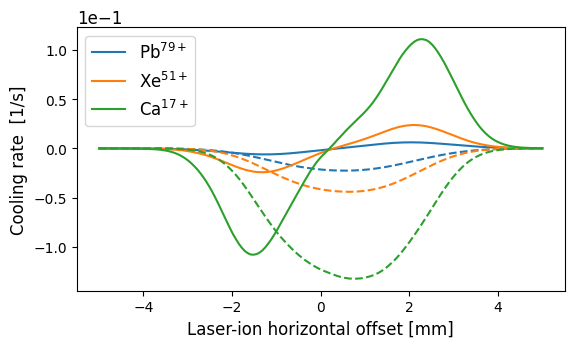

In [18]:
plt.figure(figsize=(fig_width, fig_height))

image_name_list=['lead','xenon','calcium']

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i,ion_loop in enumerate([lead,xenon,calcium]):# Ion properties:       
    data = np.load(f'results/optimal_laser_x/{ion_loop.name}.npz')

    # Access the variables stored in the file
    transverse_growth_rate_list = data['transverse_growth_rate_list']
    final_emittance_list = data['final_emittance_list']
    final_dp_p=data['final_dp_p']
    longitudinal_growth_rate_emittance_list=data['longitudinal_growth_rate_emittance_list']
    longitudinal_growth_rate_dp_p_list=data['longitudinal_growth_rate_dp_p_list']
    laser_x_list = data['laser_x_list']
    nemitt = data['nemitt']
    time = data['time']

    ######################################################################
    # Find laser position with minimal final emittance

    min_index = np.argmin(final_emittance_list)
    min_emittance = final_emittance_list[min_index]
    min_laser_offset_transverse = laser_x_list[min_index]

    min_longitudinal_index = np.argmin(final_dp_p)
    min_laser_offset_longitudinal = laser_x_list[min_longitudinal_index]

    print('min laser_offset horizontal:',min_laser_offset_transverse*1e3)    
    print('min laser offset longitudinal:',min_laser_offset_longitudinal*1e3)    
    
    
    plt.plot(laser_x_list*1e3,transverse_growth_rate_list,label=f'{ion_loop.name}',color=cycle[i])
    plt.plot(laser_x_list*1e3,longitudinal_growth_rate_emittance_list,color=cycle[i],ls='--')
    
    plt.xlabel('Laser-ion horizontal offset [mm]', fontsize=label_fontsize)
    plt.ylabel('Cooling rate  [1/s]', fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    ax = plt.gca()
    # Removing the offset from the y-axis tick labels
    ax.yaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.offsetText.set_fontsize(legend_fontsize)  # Reduce font size
    # plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    # plt.axvline(-1.3758389261744963*1e-3,color='red',label='opt. transverse cooling')
    #plt.axvline(-0.5033557046979862*1e-3,color='black',label='counteract IBS')
    
    # plt.ylim([-0.36,0.35])
plt.tight_layout()
plt.legend(fontsize=legend_fontsize)


# Save image
image_name = 'cooling_rate_total_ions.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'cooling_rate_total_ions.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

# Display the plot
plt.show()

fraction excitated displacement

min laser_offset horizontal: -1.2416107382550332
min laser offset longitudinal: 0.5704697986577186
min laser_offset horizontal: -1.3087248322147649
min laser offset longitudinal: 0.5704697986577186
min laser_offset horizontal: -1.5100671140939594
min laser offset longitudinal: 0.7718120805369133


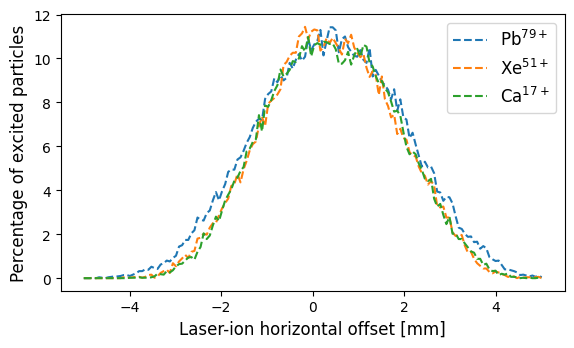

In [19]:
plt.figure(figsize=(fig_width, fig_height))

image_name_list=['lead','xenon','calcium']

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i,ion_loop in enumerate([lead,xenon,calcium]):# Ion properties:       
    data = np.load(f'results/optimal_laser_x/{ion_loop.name}.npz')

    # Access the variables stored in the file
    transverse_growth_rate_list = data['transverse_growth_rate_list']
    final_emittance_list = data['final_emittance_list']
    final_dp_p=data['final_dp_p']
    longitudinal_growth_rate_emittance_list=data['longitudinal_growth_rate_emittance_list']
    longitudinal_growth_rate_dp_p_list=data['longitudinal_growth_rate_dp_p_list']
    laser_x_list = data['laser_x_list']
    nemitt = data['nemitt']
    time = data['time']
    fraction_excited_list=data['fraction_excited_list']

    ######################################################################
    # Find laser position with minimal final emittance

    min_index = np.argmin(final_emittance_list)
    min_emittance = final_emittance_list[min_index]
    min_laser_offset_transverse = laser_x_list[min_index]

    min_longitudinal_index = np.argmin(final_dp_p)
    min_laser_offset_longitudinal = laser_x_list[min_longitudinal_index]

    print('min laser_offset horizontal:',min_laser_offset_transverse*1e3)    
    print('min laser offset longitudinal:',min_laser_offset_longitudinal*1e3)    
    
    
    #plt.plot(laser_x_list*1e3,transverse_growth_rate_list,label=f'{ion_loop.name}',color=cycle[i])
    plt.plot(laser_x_list*1e3,fraction_excited_list*100,label=f'{ion_loop.name}',color=cycle[i],ls='--')
    
    plt.xlabel('Laser-ion horizontal offset [mm]', fontsize=label_fontsize)
    plt.ylabel('Percentage of excited particles', fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    ax = plt.gca()
    # Removing the offset from the y-axis tick labels
    ax.yaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.offsetText.set_fontsize(legend_fontsize)  # Reduce font size
    # plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    # plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    # plt.axvline(-1.3758389261744963*1e-3,color='red',label='opt. transverse cooling')
    #plt.axvline(-0.5033557046979862*1e-3,color='black',label='counteract IBS')
    
    # plt.ylim([-0.36,0.35])
plt.tight_layout()
plt.legend(fontsize=legend_fontsize)

# Save image
image_name = 'fraction_excited.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'fraction_excited.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

# Display the plot
plt.show()